In [69]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [58]:
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [59]:
DATASET_PATH = "flowers"   # change if needed
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10


In [60]:
image_paths = []
labels = []
class_names = sorted(os.listdir(DATASET_PATH))

for idx, class_name in enumerate(class_names):
    class_folder = os.path.join(DATASET_PATH, class_name)
    if not os.path.isdir(class_folder):
        continue

    for file in os.listdir(class_folder):
        file_path = os.path.join(class_folder, file)
        image_paths.append(file_path)
        labels.append(idx)

print("Total files found:", len(image_paths))

Total files found: 11200


In [61]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)


In [62]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image, channels=3, try_recover_truncated=True)
    image = tf.image.resize(image, IMG_SIZE)
    return image, label

def create_dataset(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.apply(tf.data.experimental.ignore_errors())
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_paths, train_labels)
val_ds = create_dataset(val_paths, val_labels)

num_classes = len(class_names)
print("Classes:", class_names)


Classes: ['bellflower', 'daisy', 'dandelion', 'lotus', 'rose', 'sunflower', 'tulip']


In [63]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


In [64]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [65]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_8 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 lambda_4 (Lambda)           (None, 224, 224, 3)       0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_4   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_4 (Dropout)         (None, 1280)              0         
                                                                 
 dense_4 (Dense)             (None, 7)                

In [66]:
early_stop = EarlyStopping(patience=3, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    "best_flower_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [67]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

model.save("flower_classifier.keras")
print("Model saved successfully")


Epoch 1/10
280/280 [==============================] - 43s 143ms/step - loss: 0.7380 - accuracy: 0.7422 - val_loss: 0.3902 - val_accuracy: 0.8732
Epoch 2/10
280/280 [==============================] - 52s 184ms/step - loss: 0.4061 - accuracy: 0.8666 - val_loss: 0.3219 - val_accuracy: 0.8995
Epoch 3/10
280/280 [==============================] - 38s 137ms/step - loss: 0.3458 - accuracy: 0.8842 - val_loss: 0.2931 - val_accuracy: 0.9089
Epoch 4/10
280/280 [==============================] - 60s 213ms/step - loss: 0.3143 - accuracy: 0.8980 - val_loss: 0.2867 - val_accuracy: 0.9067
Epoch 5/10
280/280 [==============================] - 41s 147ms/step - loss: 0.2942 - accuracy: 0.9000 - val_loss: 0.2763 - val_accuracy: 0.9151
Epoch 6/10
280/280 [==============================] - 58s 207ms/step - loss: 0.2918 - accuracy: 0.8989 - val_loss: 0.2720 - val_accuracy: 0.9151
Epoch 7/10
280/280 [==============================] - 47s 166ms/step - loss: 0.2826 - accuracy: 0.9033 - val_loss: 0.2631 - val_ac

In [68]:
for images, labels in val_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0]
    break

sample_image_expanded = tf.expand_dims(sample_image, axis=0)
prediction = model.predict(sample_image_expanded)

predicted_class = class_names[np.argmax(prediction)]
true_class = class_names[int(sample_label)]

print("True label:", true_class)
print("Predicted label:", predicted_class)

1/1 [==============================] - 0s 437ms/step
True label: daisy
Predicted label: daisy


In [70]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 [==============================] - 0s 26ms/step


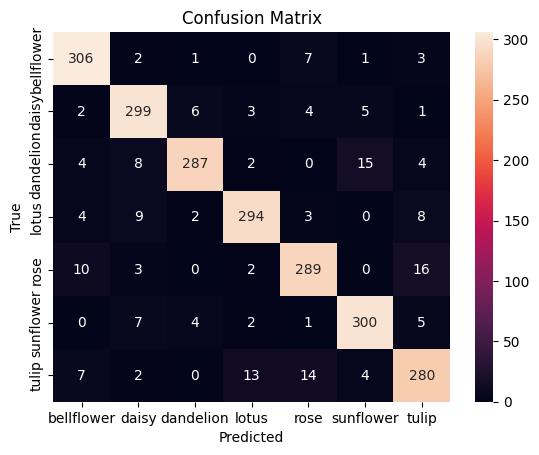

In [71]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [72]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:

              precision    recall  f1-score   support

  bellflower       0.92      0.96      0.94       320
       daisy       0.91      0.93      0.92       320
   dandelion       0.96      0.90      0.93       320
       lotus       0.93      0.92      0.92       320
        rose       0.91      0.90      0.91       320
   sunflower       0.92      0.94      0.93       319
       tulip       0.88      0.88      0.88       320

    accuracy                           0.92      2239
   macro avg       0.92      0.92      0.92      2239
weighted avg       0.92      0.92      0.92      2239



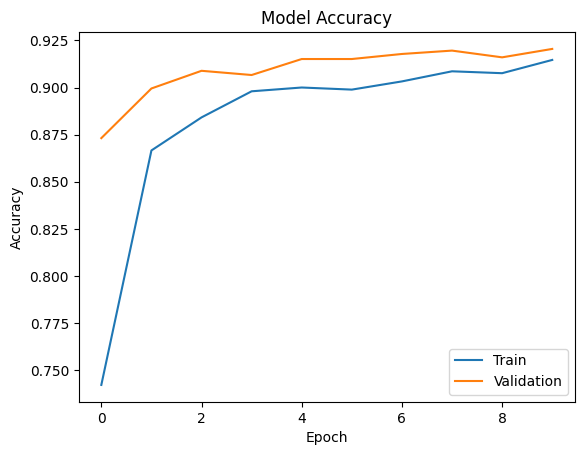

In [73]:
history_dict = history.history

plt.figure()
plt.plot(history_dict['accuracy'])
plt.plot(history_dict['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

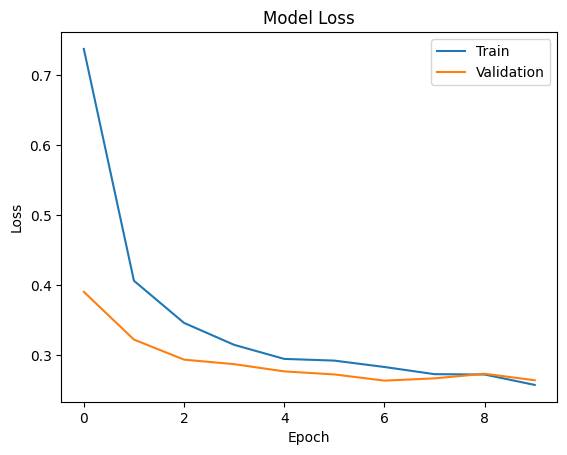

In [74]:
plt.figure()
plt.plot(history_dict['loss'])
plt.plot(history_dict['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()